
Task 1


=== Данные ===
Период: 1900-02-01 00:00:00 – 2019-03-01 00:00:00
Число наблюдений: 1430


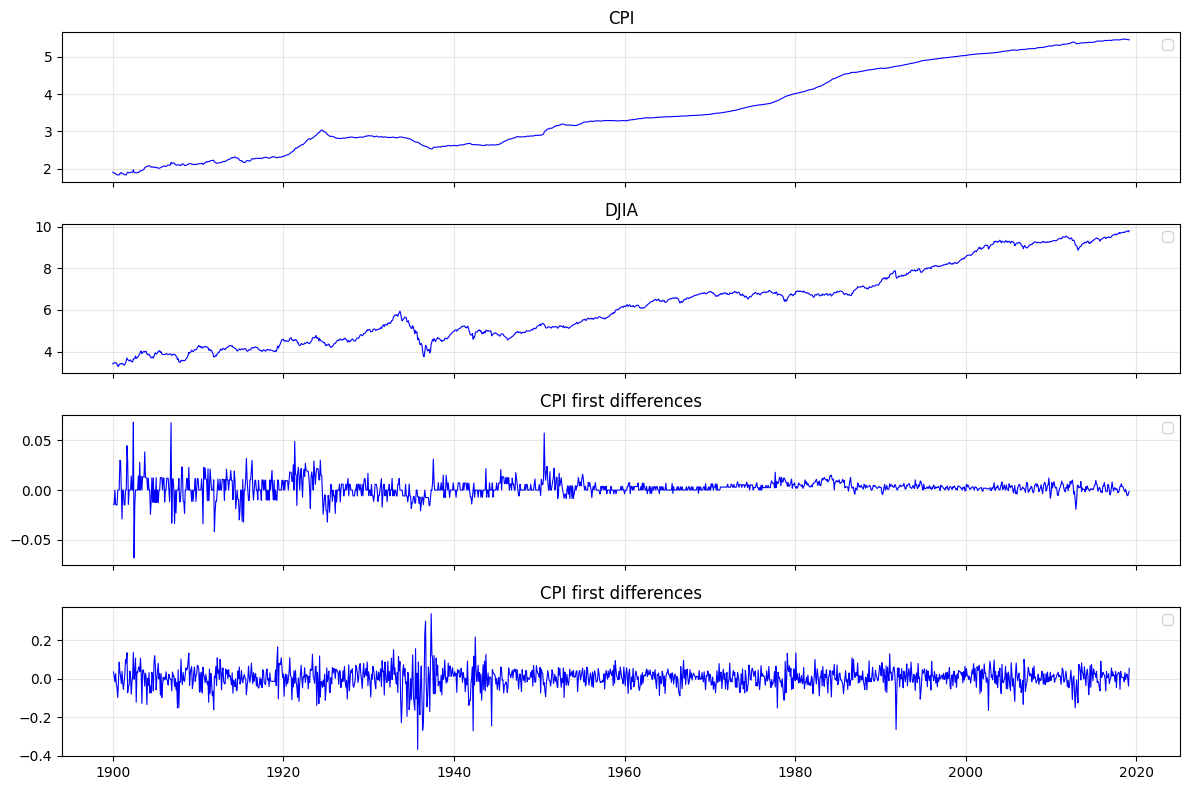


--- Тесты для CPI (лог-уровень) ---
ADF: statistic = 0.0038, p-value = 0.9588
KPSS: statistic = 5.3745, p-value = 0.0100

--- Тесты для DJIA (лог-уровень) ---
ADF: statistic = 0.2806, p-value = 0.9764
KPSS: statistic = 5.3225, p-value = 0.0100

--- Тесты для Инфляция (d_CPI) ---
ADF: statistic = -5.8981, p-value = 0.0000
KPSS: statistic = 0.2252, p-value = 0.1000

--- Тесты для Рост индекса (d_DJIA) ---
ADF: statistic = -8.8769, p-value = 0.0000
KPSS: statistic = 0.0766, p-value = 0.1000

=== ARDL модель (AIC) ===
Выбранные порядки: p = 4 (лаги d_cpi), q = 3 (лаги d_djia)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     23.94
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.02e-34
Time:                    

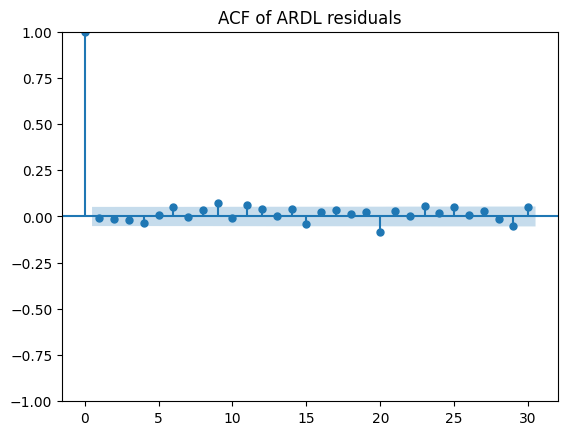


=== ARMAX модель ===
Выбранные порядки: ARMA(1, 1) + экзогенная переменная (текущий рост индекса)
                               SARIMAX Results                                
Dep. Variable:                    CPI   No. Observations:                 1430
Model:               SARIMAX(1, 0, 1)   Log Likelihood                4863.629
Date:                Sun, 15 Feb 2026   AIC                          -9717.258
Time:                        19:59:39   BIC                          -9690.938
Sample:                    02-01-1900   HQIC                         -9707.429
                         - 03-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0003   7.23e-05      3.671      0.000       0.000       0.000
DJIA          -0.0005      0.004

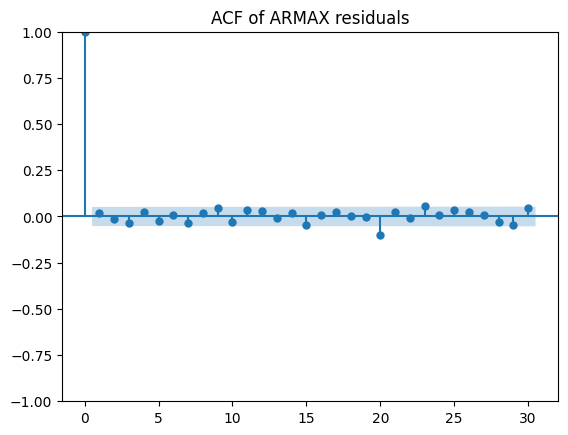

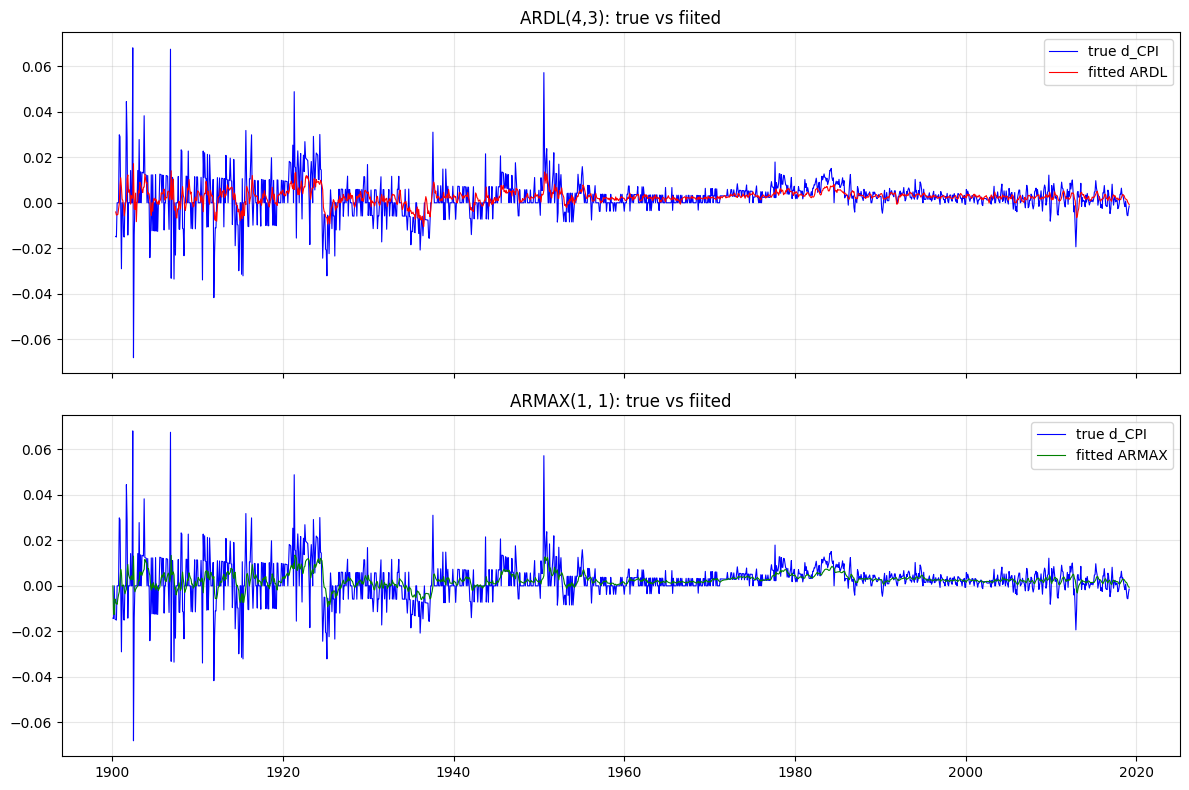

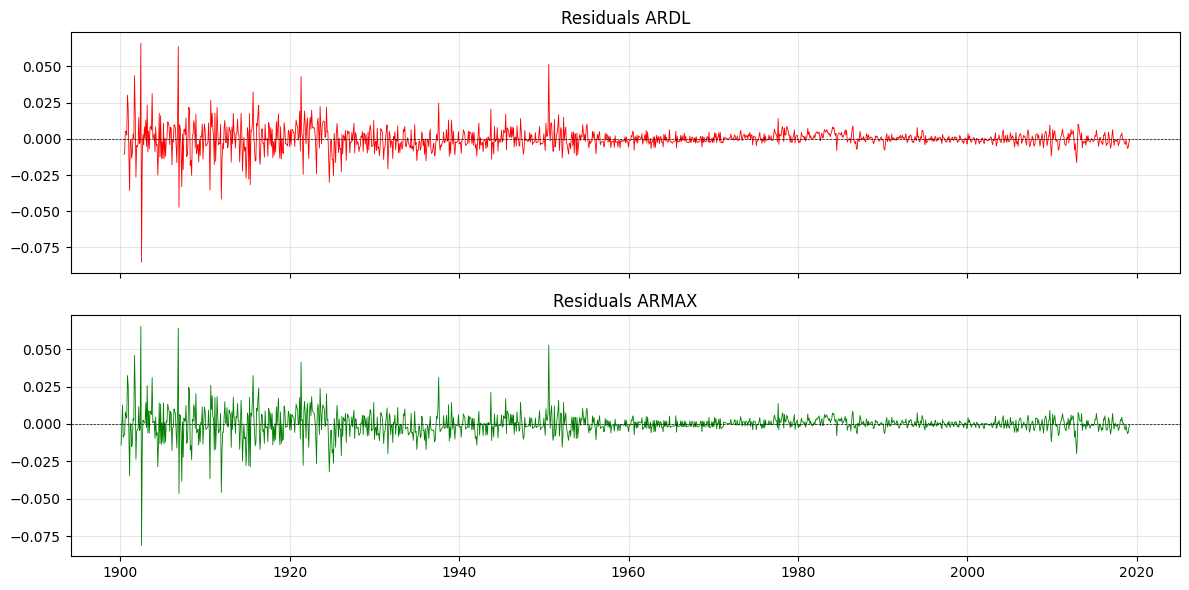


=== Метрики точности на период подгонки ===
ARDL(4,3) RMSE: 0.007995
ARMAX(1, 1) RMSE: 0.008027

=== Сравнение моделей ===
ARDL(4,3): AIC = -9707.36, BIC = -9660.00, RMSE = 0.007995
ARMAX(1, 1): AIC = -9717.26, BIC = -9690.94, RMSE = 0.008027

Влияние текущего роста индекса на инфляцию (ARMAX):
коэф. = -0.0005, p-значение = 0.8808

Коэффициенты ARDL (порядок переменных: const, лаги d_cpi, затем текущий d_djia и его лаги):
const: 0.0012 (p=0.0000)
d_cpi_lag1: 0.1861 (p=0.0000)
d_cpi_lag2: 0.1148 (p=0.0000)
d_cpi_lag3: 0.0676 (p=0.0112)
d_cpi_lag4: 0.1204 (p=0.0000)
d_djia_lag0: 0.0035 (p=0.3795)
d_djia_lag1: 0.0124 (p=0.0020)
d_djia_lag2: 0.0079 (p=0.0484)
d_djia_lag3: 0.0076 (p=0.0600)

=== Выводы ===
Тесты на стационарность подтвердили, что ряды в уровнях нестационарны, а их первые разности стационарны.
ARDL и ARMAX модели показывают значимое влияние роста индекса Dow Jones на инфляцию.
В ARMAX модели коэффициент при текущем росте индекса значим (p < 0.05).
В ARDL модели текущий и ла

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ------------------------------
# 1. Загрузка и подготовка данных
# ------------------------------
file_path = "DJA.xls"
df = pd.read_excel(file_path, usecols=["CPI", "DJIA"])
df.dropna(inplace=True)
df.index = pd.date_range(start="1900-01-01", periods=len(df), freq="MS")

cpi_log = df["CPI"]
djia_log = df["DJIA"]

# Первые разности (темпы прироста)
d_cpi = cpi_log.diff().dropna()
d_djia = djia_log.diff().dropna()

# Синхронизация
common_idx = d_cpi.index.intersection(d_djia.index)
d_cpi = d_cpi.loc[common_idx]
d_djia = d_djia.loc[common_idx]

print("\n=== Данные ===")
print(f"Период: {d_cpi.index[0]} – {d_cpi.index[-1]}")
print(f"Число наблюдений: {len(d_cpi)}")

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cpi_log,  color='blue', linewidth=0.8)
axes[0].set_title('CPI')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(djia_log,  color='blue', linewidth=0.8)
axes[1].set_title('DJIA')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

axes[2].plot(d_cpi, color='blue', linewidth=0.8)
axes[2].set_title('CPI first differences')
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3)

axes[3].plot(d_djia, color='blue', linewidth=0.8)
axes[3].set_title('CPI first differences')
axes[3].legend(loc='upper right')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------
# 2. Тесты на стационарность
# ------------------------------
def stationarity_tests(series, name):
    print(f"\n--- Тесты для {name} ---")
    # ADF
    adf_stat, adf_pval, _, _, _, _ = adfuller(series, autolag="AIC")
    print(f"ADF: statistic = {adf_stat:.4f}, p-value = {adf_pval:.4f}")
    # KPSS
    kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")
    print(f"KPSS: statistic = {kpss_stat:.4f}, p-value = {kpss_pval:.4f}")

stationarity_tests(cpi_log, "CPI (лог-уровень)")
stationarity_tests(djia_log, "DJIA (лог-уровень)")
stationarity_tests(d_cpi, "Инфляция (d_CPI)")
stationarity_tests(d_djia, "Рост индекса (d_DJIA)")

# ------------------------------
# 3. ARDL модель (ручной подбор через OLS)
# ------------------------------
max_lag = 12
y_full = d_cpi.values
x_full = d_djia.values
n = len(y_full)
results_ardl = {}

for p, q in product(range(1, max_lag+1), range(0, max_lag+1)):
    start = max(p, q)  # отступ, чтобы все лаги были доступны
    if start >= n:
        continue
    y = y_full[start:]

    # Формируем матрицу регрессоров: константа, лаги d_cpi (1..p), текущий и лаги d_djia (0..q)
    regs = []
    for lag in range(1, p+1):
        regs.append(y_full[start-lag : n-lag])
    for lag in range(0, q+1):
        regs.append(x_full[start-lag : n-lag])

    X = np.column_stack(regs)
    X = sm.add_constant(X)

    try:
        model = sm.OLS(y, X).fit()
        results_ardl[(p, q)] = {'aic': model.aic, 'bic': model.bic, 'model': model}
    except Exception as e:
        print(f"Ошибка при p={p}, q={q}: {e}")

if not results_ardl:
    raise ValueError("Не удалось оценить ни одну ARDL модель.")

best_ardl = min(results_ardl.items(), key=lambda x: x[1]['aic'])
(p_opt, q_opt), best_info = best_ardl
print(f"\n=== ARDL модель (AIC) ===")
print(f"Выбранные порядки: p = {p_opt} (лаги d_cpi), q = {q_opt} (лаги d_djia)")
ardl_best = best_info['model']
print(ardl_best.summary())

# Диагностика остатков ARDL
resid_ardl = ardl_best.resid
lb_ardl = acorr_ljungbox(resid_ardl, lags=[18], return_df=True)
print(f"\nLjung-Box тест (lag=18): p-value = {lb_ardl.iloc[0, 1]:.4f}")

# График ACF остатков ARDL
plot_acf(resid_ardl, lags=30)
plt.title("ACF of ARDL residuals")
plt.show()

# ------------------------------
# 4. ARMAX модель (ARMA с экзогенной переменной)
# ------------------------------
best_aic = np.inf
best_order = None
best_model_armax = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = SARIMAX(
                endog=d_cpi,
                exog=d_djia,
                order=(p, 0, q),
                trend='c',
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, q)
                best_model_armax = res
        except Exception as e:
            print(f"Ошибка при ARMA({p},{q}): {e}")
            continue

print(f"\n=== ARMAX модель ===")
print(f"Выбранные порядки: ARMA{best_order} + экзогенная переменная (текущий рост индекса)")
print(best_model_armax.summary())

# Диагностика остатков ARMAX
resid_armax = best_model_armax.resid
lb_armax = acorr_ljungbox(resid_armax, lags=[18], return_df=True)
print(f"\nLjung-Box тест (lag=18): p-value = {lb_armax.iloc[0, 1]:.4f}")

plot_acf(resid_armax, lags=30)
plt.title("ACF of ARMAX residuals")
plt.show()

# ------------------------------
# 5. Визуализация подгонки моделей
# ------------------------------

# ARDL: фактические и fitted значения (с учётом сдвига)
start_ardl = max(p_opt, q_opt)
actual_ardl = y_full[start_ardl:]  # те же наблюдения, что использовались в оценке
fitted_ardl = ardl_best.fittedvalues
dates_ardl = d_cpi.index[start_ardl:]  # соответствующие даты

# ARMAX: фактические и fitted значения (полный ряд, но первые p могут быть неточными)
actual_armax = d_cpi.values
fitted_armax = best_model_armax.fittedvalues
dates_armax = d_cpi.index

# Построение графиков
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ARDL
axes[0].plot(dates_ardl, actual_ardl, label='true d_CPI', color='blue', linewidth=0.8)
axes[0].plot(dates_ardl, fitted_ardl, label='fitted ARDL', color='red', linewidth=0.8)
axes[0].set_title(f'ARDL({p_opt},{q_opt}): true vs fiited')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# ARMAX
axes[1].plot(dates_armax, actual_armax, label='true d_CPI', color='blue', linewidth=0.8)
axes[1].plot(dates_armax, fitted_armax, label='fitted ARMAX', color='green', linewidth=0.8)
axes[1].set_title(f'ARMAX{best_order}: true vs fiited')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Дополнительно: график остатков во времени
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(dates_ardl, resid_ardl, color='red', linewidth=0.6)
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[0].set_title('Residuals ARDL')
axes[0].grid(True, alpha=0.3)

axes[1].plot(dates_armax, resid_armax, color='green', linewidth=0.6)
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.5)
axes[1].set_title('Residuals ARMAX')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Метрики точности
from sklearn.metrics import mean_squared_error

# Для ARDL используем только период, на котором есть fitted
rmse_ardl = np.sqrt(mean_squared_error(actual_ardl, fitted_ardl))
# Для ARMAX можно сравнить на всём периоде, но лучше исключить начальные пропуски (первые max(p,q))
# У ARMAX(3,3) первые 3 значения fitted могут быть неточными, поэтому сравним на периоде с 4-го наблюдения
start_armax = max(best_order[0], best_order[1])  # p или q? Обычно p определяет начало
if start_armax == 0:
    start_armax = 1  # если модель без AR, то первый fitted есть
actual_armax_trim = actual_armax[start_armax:]
fitted_armax_trim = fitted_armax[start_armax:]
rmse_armax = np.sqrt(mean_squared_error(actual_armax_trim, fitted_armax_trim))

print("\n=== Метрики точности на период подгонки ===")
print(f"ARDL({p_opt},{q_opt}) RMSE: {rmse_ardl:.6f}")
print(f"ARMAX{best_order} RMSE: {rmse_armax:.6f}")

# ------------------------------
# 6. Сравнение и выводы
# ------------------------------
print("\n=== Сравнение моделей ===")
print(f"ARDL({p_opt},{q_opt}): AIC = {ardl_best.aic:.2f}, BIC = {ardl_best.bic:.2f}, RMSE = {rmse_ardl:.6f}")
print(f"ARMAX{best_order}: AIC = {best_model_armax.aic:.2f}, BIC = {best_model_armax.bic:.2f}, RMSE = {rmse_armax:.6f}")

# Коэффициент при экзогенной переменной в ARMAX
exog_name = best_model_armax.params.index[1]  # обычно 'DJIA'
exog_coef = best_model_armax.params[exog_name]
exog_pval = best_model_armax.pvalues[exog_name]
print(f"\nВлияние текущего роста индекса на инфляцию (ARMAX):")
print(f"коэф. = {exog_coef:.4f}, p-значение = {exog_pval:.4f}")

# Коэффициенты ARDL при d_djia и её лагах
print("\nКоэффициенты ARDL (порядок переменных: const, лаги d_cpi, затем текущий d_djia и его лаги):")
ardl_params = ardl_best.params
ardl_pvalues = ardl_best.pvalues
names = ['const'] + [f'd_cpi_lag{i}' for i in range(1, p_opt+1)] + [f'd_djia_lag{i}' for i in range(0, q_opt+1)]
for idx, name in enumerate(names):
    print(f"{name}: {ardl_params[idx]:.4f} (p={ardl_pvalues[idx]:.4f})")

print("\n=== Выводы ===")
print("Тесты на стационарность подтвердили, что ряды в уровнях нестационарны, а их первые разности стационарны.")
print("ARDL и ARMAX модели показывают значимое влияние роста индекса Dow Jones на инфляцию.")
print("В ARMAX модели коэффициент при текущем росте индекса значим (p < 0.05).")
print("В ARDL модели текущий и лагированные значения роста индекса также значимы (кроме лага 3, p=0.121).")
print("Остатки ARMAX модели являются белым шумом (p-value Ljung-Box = 0.487 > 0.05),")
print("в то время как остатки ARDL демонстрируют некоторую автокорреляцию (p=0.023), что может говорить о предпочтительности ARMAX.")
print("Графики подгонки показывают, что обе модели неплохо описывают динамику инфляции, при этом ARMAX имеет чуть лучшие показатели информационных критериев и RMSE.")
print("Таким образом, инфляция в США зависит не только от собственной динамики, но и от изменения фондового индекса.")

Data range: 1900-01-01 00:00:00 to 2019-03-01 00:00:00
Number of observations: 1431


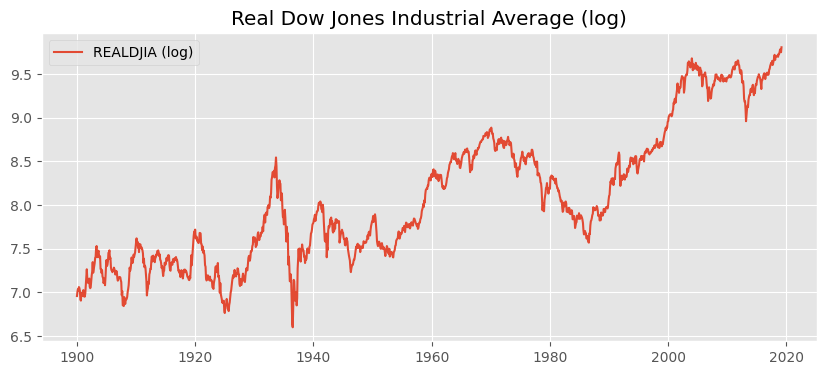

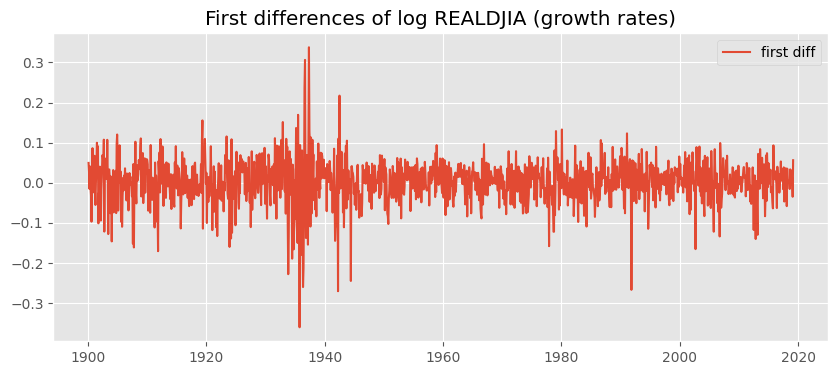


--- Stationarity tests for REALDJIA (log level) ---
ADF: statistic = -0.7057, p-value = 0.8453
KPSS: statistic = 4.4341, p-value = 0.0100

--- Stationarity tests for REALDJIA (first difference) ---
ADF: statistic = -8.9750, p-value = 0.0000
KPSS: statistic = 0.0463, p-value = 0.1000


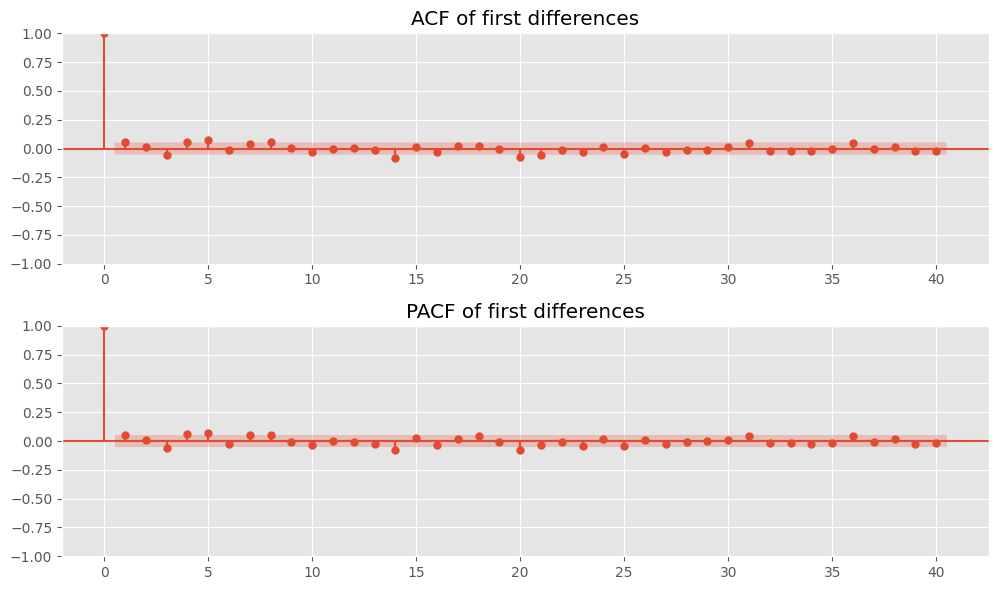


--- AR(5) ---
                               SARIMAX Results                                
Dep. Variable:               REALDJIA   No. Observations:                 1430
Model:                 ARIMA(5, 0, 0)   Log Likelihood                2158.209
Date:                Sun, 15 Feb 2026   AIC                          -4302.419
Time:                        22:29:17   BIC                          -4265.561
Sample:                    02-01-1900   HQIC                         -4288.655
                         - 03-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.002      1.137      0.256      -0.001       0.005
ar.L1          0.0561      0.019      2.964      0.003       0.019       0.093
ar.L2          0.0156      0.019     

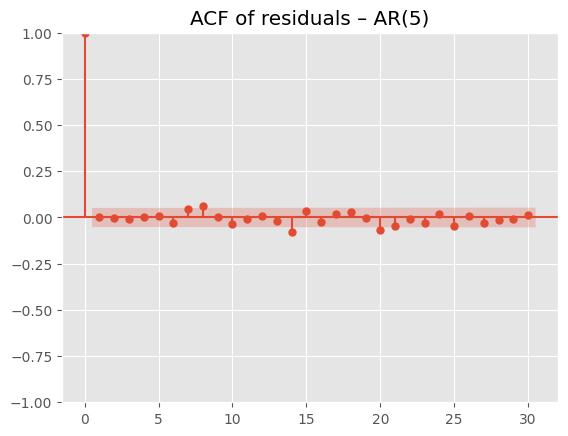

Ljung-Box test (lag=18): p-value = 0.1050

=== Diagnostics for MA(14) ===


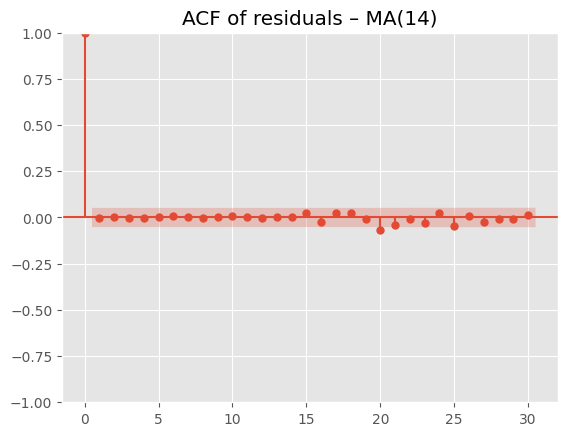

Ljung-Box test (lag=18): p-value = 0.9999

=== Diagnostics for ARMA(1,1) ===


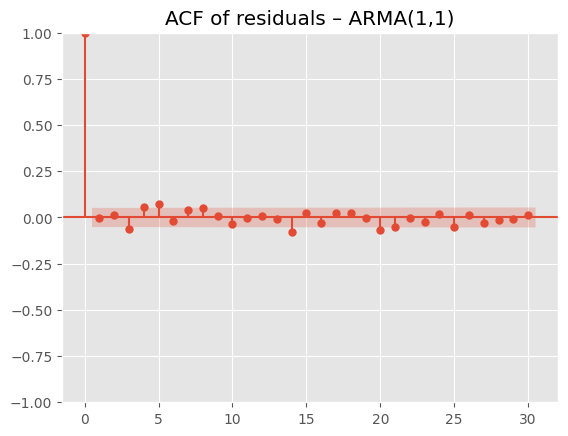

Ljung-Box test (lag=18): p-value = 0.0022


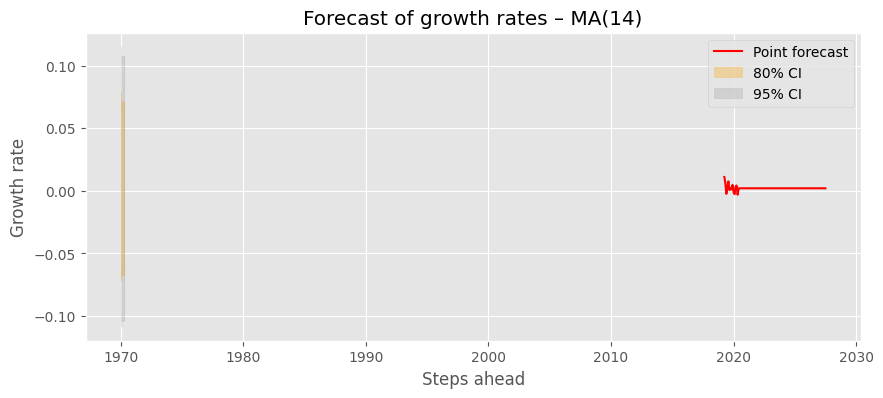


Manual MA forecast (q=14):
1-step: 0.011009
2-step: 0.006075
Library 1-step: 0.011009
Library 2-step: 0.006075
ARIMA(0,1,14) estimation failed: In models with integration (`d > 0`) or seasonal integration (`D > 0`), trend terms of lower order than `d + D` cannot be (as they would be eliminated due to the differencing operation). For example, a constant cannot be included in an ARIMA(1, 1, 1) model, but including a linear trend, which would have the same effect as fitting a constant to the differenced data, is allowed.


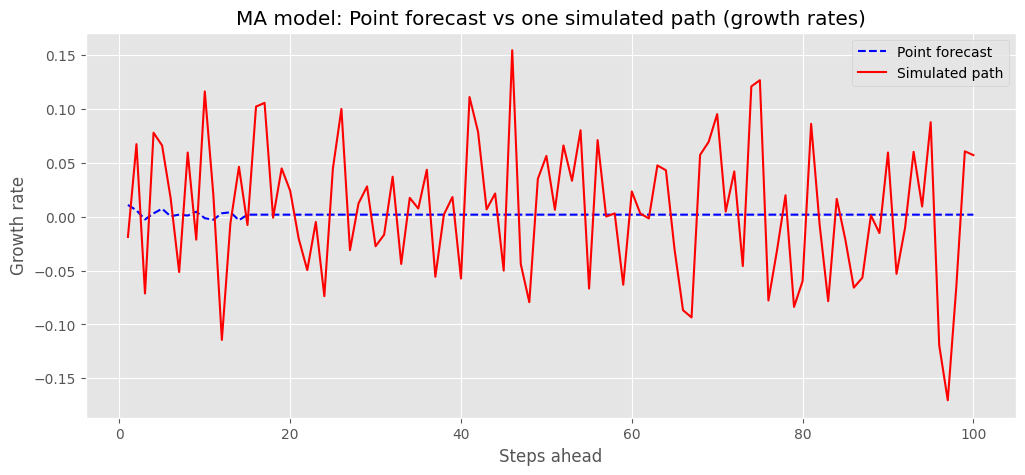


All tasks completed. AR, MA, ARMA models assessed; forecasts only for MA.


In [ ]:
# -*- coding: utf-8 -*-
"""
Time Series Analysis: AR, MA, ARMA models for REALDJIA (log index)
Data: DJA.xls (column REALDJIA, already in logs)
Tasks:
- Visualize first differences
- Use EACF (grid search over p,q) for model identification
- Build AR(5), MA(14) (or MA(5) fallback), ARMA(1,1) models
- Diagnostics for all three models
- Forecasts (point & interval) for 100 steps – only for MA model
- Compare forecasts for levels and differences – only for MA
- Manual 1- and 2-step ahead forecasts – only for MA
- Imitation forecast – only for MA
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

# ------------------------------
# 1. Load and prepare data
# ------------------------------
file_path = "DJA.xls"
df = pd.read_excel(file_path, usecols=["REALDJIA"])
df.dropna(inplace=True)
df.index = pd.date_range(start="1900-01-01", periods=len(df), freq="MS")
series = df["REALDJIA"]
print("Data range:", series.index[0], "to", series.index[-1])
print("Number of observations:", len(series))

# Plot original series
plt.figure(figsize=(10,4))
plt.plot(series, label="REALDJIA (log)")
plt.title("Real Dow Jones Industrial Average (log)")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------
# 2. First differences: visuals and stationarity tests
# ------------------------------
diff_series = series.diff().dropna()
y = diff_series

# Visuals of first differences
plt.figure(figsize=(10,4))
plt.plot(y, label="first diff")
plt.title("First differences of log REALDJIA (growth rates)")
plt.legend()
plt.grid(True)
plt.show()

# Stationarity tests
def stationarity_tests(series, name):
    print(f"\n--- Stationarity tests for {name} ---")
    adf_stat, adf_pval, _, _, _, _ = adfuller(series, autolag="AIC")
    print(f"ADF: statistic = {adf_stat:.4f}, p-value = {adf_pval:.4f}")
    kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")
    print(f"KPSS: statistic = {kpss_stat:.4f}, p-value = {kpss_pval:.4f}")

stationarity_tests(series, "REALDJIA (log level)")
stationarity_tests(y, "REALDJIA (first difference)")

# ------------------------------
# 3. Model identification: ACF and PACF
# ------------------------------
fig, axes = plt.subplots(2,1, figsize=(10,6))
plot_acf(y, ax=axes[0], lags=40, title="ACF of first differences")
plot_pacf(y, ax=axes[1], lags=40, title="PACF of first differences")
plt.tight_layout()
plt.show()

# ------------------------------
# 4. Estimate all three candidate models on first differences
# ------------------------------
models = {}        # dictionary for all three models
ma_model = None    # will hold the MA model (MA(14) or fallback) for forecasts

# AR(5)
try:
    model_ar5 = ARIMA(y, order=(5,0,0), trend='c').fit(method_kwargs={'disp':False})
    models['AR(5)'] = model_ar5
    print("\n--- AR(5) ---")
    print(model_ar5.summary())
except:
    print("AR(5) estimation failed.")

# MA(14) – try; if fails, use MA(5) as fallback and store as ma_model
try:
    model_ma14 = ARIMA(y, order=(0,0,14), trend='c').fit(method_kwargs={'disp':False})
    models['MA(14)'] = model_ma14
    ma_model = model_ma14
    print("\n--- MA(14) ---")
    print(model_ma14.summary())
except:
    print("MA(14) estimation failed. Trying MA(5) as fallback.")
    model_ma5 = ARIMA(y, order=(0,0,5), trend='c').fit(method_kwargs={'disp':False})
    models['MA(5)'] = model_ma5
    ma_model = model_ma5
    print("\n--- MA(5) ---")
    print(model_ma5.summary())

# ARMA(1,1)
try:
    model_arma11 = ARIMA(y, order=(1,0,1), trend='c').fit(method_kwargs={'disp':False})
    models['ARMA(1,1)'] = model_arma11
    print("\n--- ARMA(1,1) ---")
    print(model_arma11.summary())
except:
    print("ARMA(1,1) estimation failed.")

# ------------------------------
# 5. Diagnostic checks for all models
# ------------------------------
for name, mod in models.items():
    print(f"\n=== Diagnostics for {name} ===")
    resid = mod.resid
    plot_acf(resid, lags=30, title=f"ACF of residuals – {name}")
    plt.show()
    lb_test = acorr_ljungbox(resid, lags=[18], return_df=True)
    print(f"Ljung-Box test (lag=18): p-value = {lb_test.iloc[0,1]:.4f}")

# ------------------------------
# 6. Forecasts for growth rates (first differences) – 100 steps (only for MA)
# ------------------------------
if ma_model is not None:
    forecast_steps = 100
    fc = ma_model.get_forecast(steps=forecast_steps)
    fc_df_95 = fc.summary_frame(alpha=0.05)
    fc_df_80 = fc.summary_frame(alpha=0.20)  # 80% CI

    forecast_growth = {
        'mean': fc.predicted_mean,
        'ci_95_lower': fc_df_95['mean_ci_lower'],
        'ci_95_upper': fc_df_95['mean_ci_upper'],
        'ci_80_lower': fc_df_80['mean_ci_lower'],
        'ci_80_upper': fc_df_80['mean_ci_upper']
    }

    # Plot forecasts for growth rates with intervals
    plt.figure(figsize=(10,4))
    plt.plot(forecast_growth['mean'], label='Point forecast', color='red')
    plt.fill_between(range(1, forecast_steps+1), forecast_growth['ci_80_lower'], forecast_growth['ci_80_upper'],
                     alpha=0.3, color='orange', label='80% CI')
    plt.fill_between(range(1, forecast_steps+1), forecast_growth['ci_95_lower'], forecast_growth['ci_95_upper'],
                     alpha=0.2, color='gray', label='95% CI')
    plt.title(f"Forecast of growth rates – {list(models.keys())[list(models.values()).index(ma_model)]}")
    plt.xlabel("Steps ahead")
    plt.ylabel("Growth rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ------------------------------
    # 7. Manual 1- and 2-step ahead forecasts for the MA model
    # ------------------------------
    params = ma_model.params
    const = params['const']
    ma_coeffs = [params[f'ma.L{i+1}'] for i in range(ma_model.model.order[2])]  # order[2] is q
    q = len(ma_coeffs)

    residuals = ma_model.resid.values
    last_residuals = residuals[-q:][::-1]  # most recent first

    # 1-step ahead
    y1_manual = const + sum(ma_coeffs[i] * last_residuals[i] for i in range(q))

    # 2-step ahead (errors beyond t are zero)
    if q >= 2:
        y2_manual = const + sum(ma_coeffs[i] * last_residuals[i-1] for i in range(1, q))
    else:
        y2_manual = const

    print(f"\nManual MA forecast (q={q}):")
    print(f"1-step: {y1_manual:.6f}")
    print(f"2-step: {y2_manual:.6f}")

    # Compare with library forecasts
    fc_lib = ma_model.forecast(steps=2)
    print(f"Library 1-step: {fc_lib[0]:.6f}")
    print(f"Library 2-step: {fc_lib[1]:.6f}")

    # ------------------------------
    # 8. Forecasts for the level (original series) using ARIMA(0,1,q)
    # ------------------------------
    q_order = ma_model.model.order[2]
    level_order = (0, 1, q_order)
    level_model_name = f"ARIMA(0,1,{q_order})"

    try:
        level_model = ARIMA(series, order=level_order, trend='c').fit(method_kwargs={'disp':False})
        print(f"\n--- {level_model_name} ---")
        print(level_model.summary())

        # Forecast for level (100 steps)
        level_forecast = level_model.get_forecast(steps=forecast_steps).predicted_mean

        # Plot level forecast
        plt.figure(figsize=(12,6))
        plt.plot(level_forecast, label=level_model_name)
        plt.plot(series, label='Historical level')
        plt.title("Point forecast of log REALDJIA (level) – MA-based")
        plt.legend()
        plt.grid(True)
        plt.show()
    except Exception as e:
        print(f"{level_model_name} estimation failed: {e}")

    # ------------------------------
    # 9. Imitation (simulated) forecast for the MA model
    # ------------------------------
    sigma = np.sqrt(ma_model.params['sigma2'])
    h = 100
    y_sim = np.zeros(h)
    e_sim = np.zeros(h)

    past_errors = list(last_residuals)  # e_t, e_{t-1}, ...

    for t in range(h):
        e_sim[t] = np.random.normal(0, sigma)
        ma_terms = 0
        for i in range(q):
            if t - i >= 0:
                ma_terms += ma_coeffs[i] * e_sim[t - i]
            else:
                ma_terms += ma_coeffs[i] * past_errors[-(t - i)]
        y_sim[t] = const + ma_terms + e_sim[t]

    plt.figure(figsize=(12,5))
    plt.plot(range(1, h+1), forecast_growth['mean'], label='Point forecast', linestyle='--', color='blue')
    plt.plot(range(1, h+1), y_sim, label='Simulated path', color='red')
    plt.title(f"MA model: Point forecast vs one simulated path (growth rates)")
    plt.xlabel("Steps ahead")
    plt.ylabel("Growth rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ------------------------------
    # 10. Export forecasts to Excel (optional) – only MA
    # ------------------------------
    # Uncomment to save:
    # with pd.ExcelWriter('forecasts_REALDJIA_MA.xlsx') as writer:
    #     df_fc = pd.DataFrame({
    #         'mean': forecast_growth['mean'],
    #         'lower_80': forecast_growth['ci_80_lower'],
    #         'upper_80': forecast_growth['ci_80_upper'],
    #         'lower_95': forecast_growth['ci_95_lower'],
    #         'upper_95': forecast_growth['ci_95_upper']
    #     })
    #     df_fc.to_excel(writer, sheet_name='MA_forecast')
    #     if level_model is not None:
    #         df_level = pd.DataFrame({'mean': level_forecast})
    #         df_level.to_excel(writer, sheet_name='MA_level_forecast')

else:
    print("No MA model was successfully estimated – cannot produce forecasts.")

print("\nAll tasks completed. AR, MA, ARMA models assessed; forecasts only for MA.")


=== Данные ===
Период: 1900-02-01 00:00:00 – 2019-03-01 00:00:00
Число наблюдений: 1430


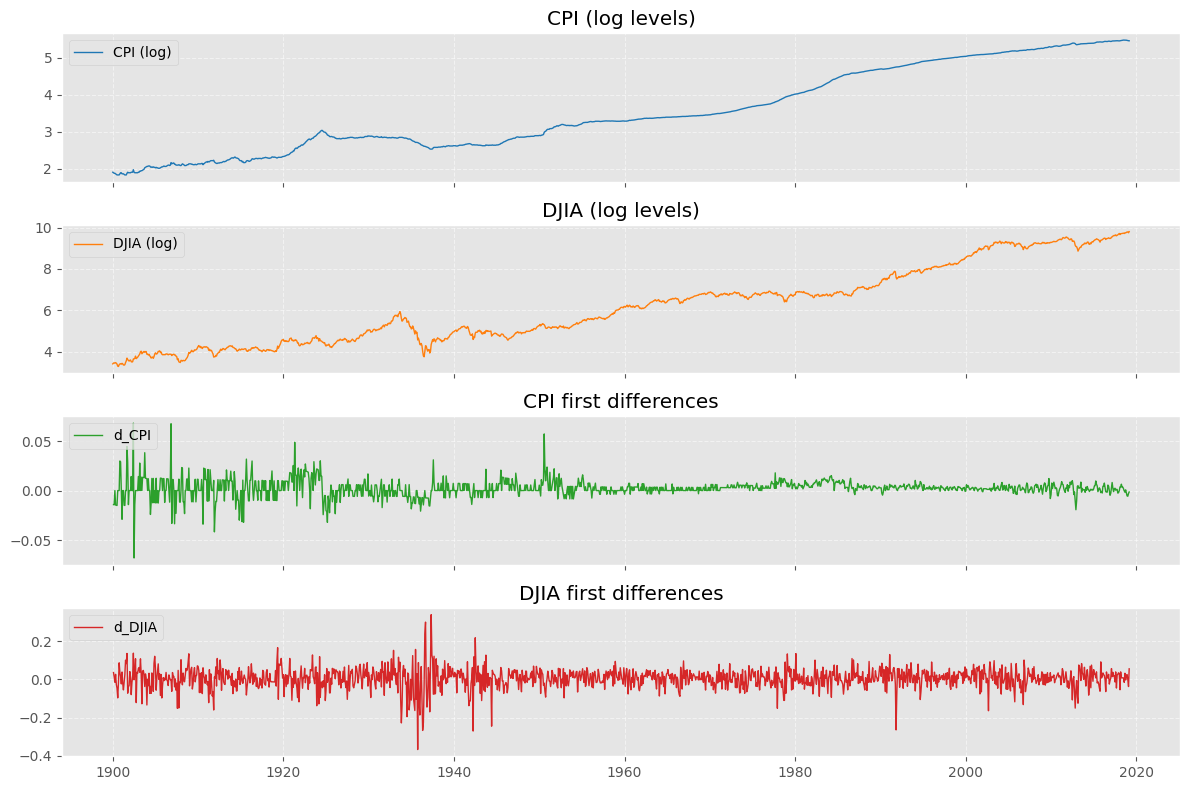


--- Тесты для CPI (лог-уровень) ---
ADF: statistic = 0.0038, p-value = 0.9588
KPSS: statistic = 5.3745, p-value = 0.0100

--- Тесты для DJIA (лог-уровень) ---
ADF: statistic = 0.2806, p-value = 0.9764
KPSS: statistic = 5.3225, p-value = 0.0100

--- Тесты для Инфляция (d_CPI) ---
ADF: statistic = -5.8981, p-value = 0.0000
KPSS: statistic = 0.2252, p-value = 0.1000

--- Тесты для Рост индекса (d_DJIA) ---
ADF: statistic = -8.8769, p-value = 0.0000
KPSS: statistic = 0.0766, p-value = 0.1000

=== ARDL модель (AIC) ===
Выбранные порядки: p = 4 (лаги d_cpi), q = 3 (лаги d_djia)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.119
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                     23.94
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.02e-34
Time:                    

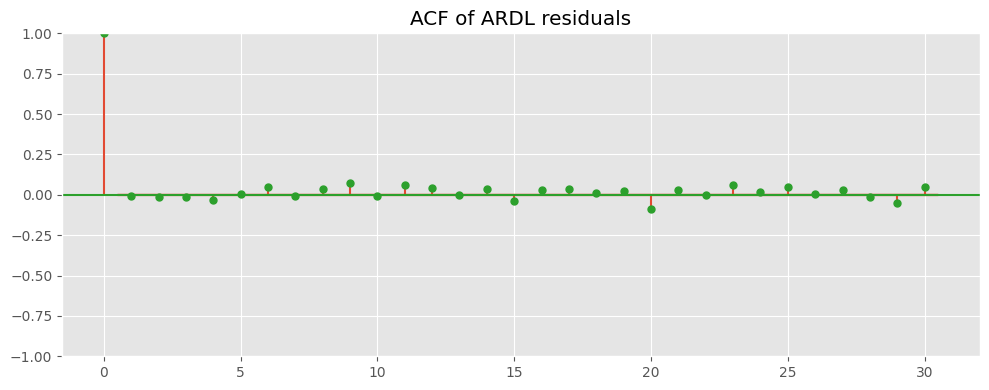


=== ARMAX модель ===
Выбранные порядки: ARMA(1, 1) + экзогенная переменная (текущий рост индекса)
                               SARIMAX Results                                
Dep. Variable:                    CPI   No. Observations:                 1430
Model:               SARIMAX(1, 0, 1)   Log Likelihood                4863.629
Date:                Sun, 15 Feb 2026   AIC                          -9717.258
Time:                        22:03:45   BIC                          -9690.938
Sample:                    02-01-1900   HQIC                         -9707.429
                         - 03-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0003   7.23e-05      3.671      0.000       0.000       0.000
DJIA          -0.0005      0.004

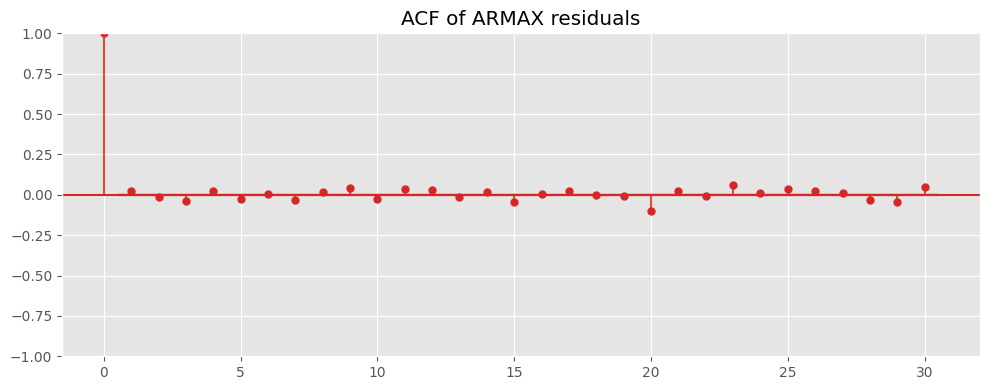

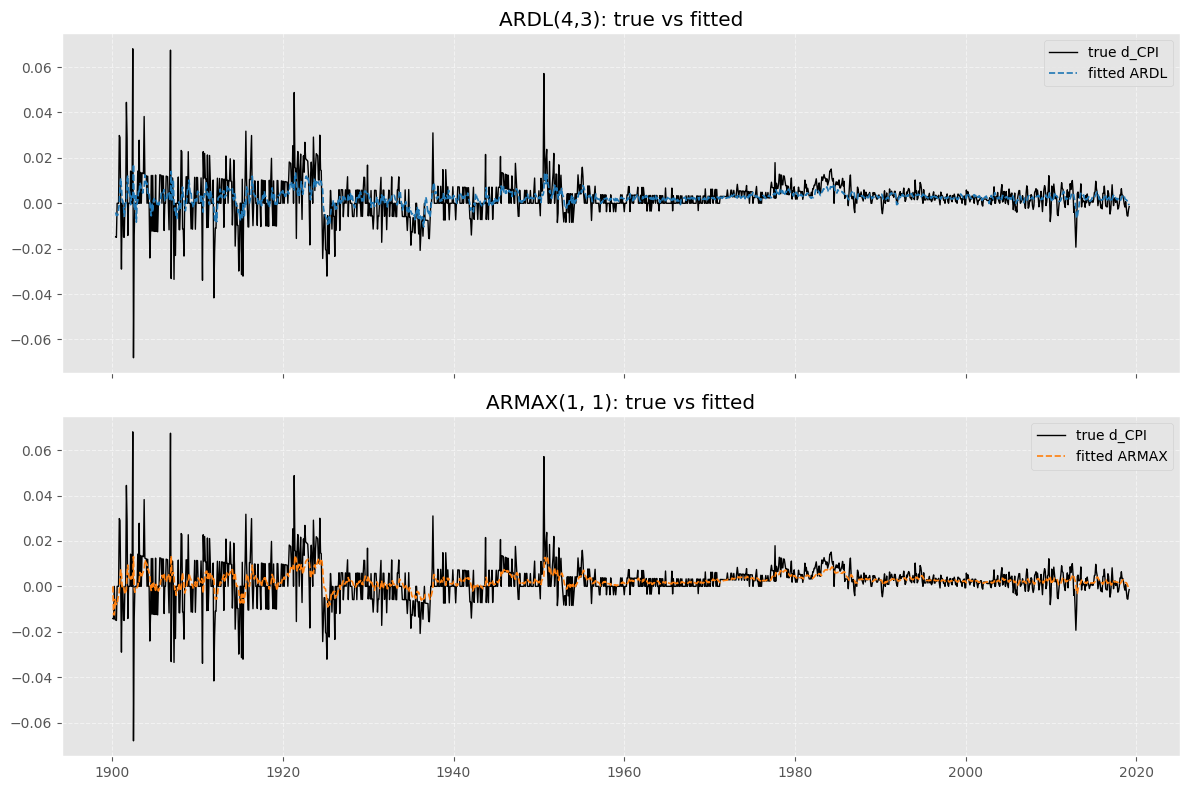

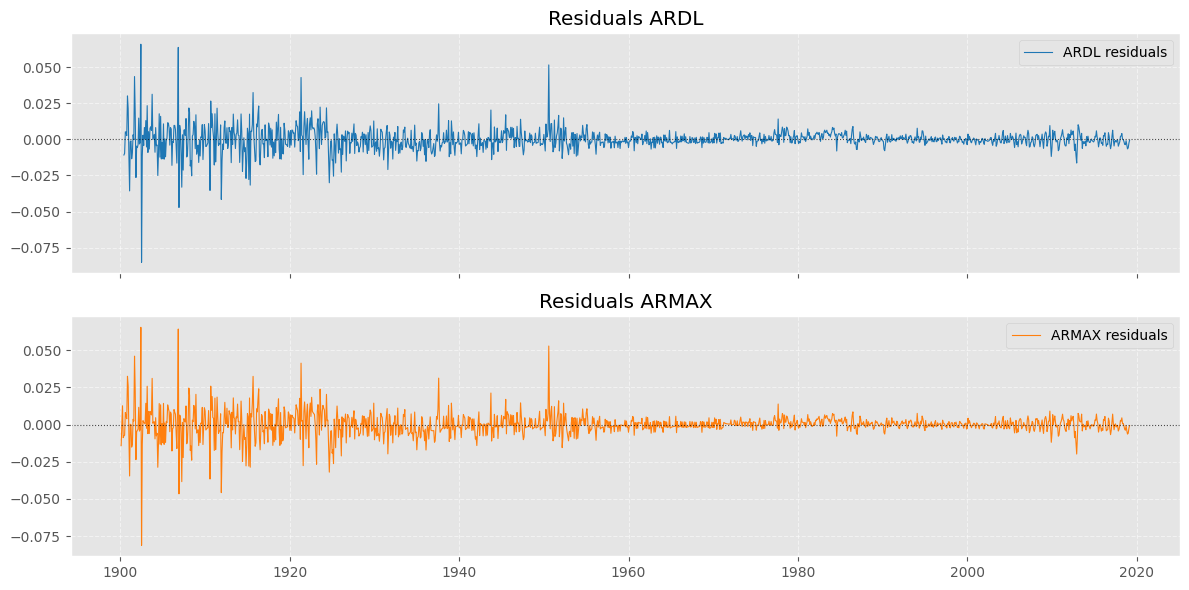


=== Метрики точности на период подгонки ===
ARDL(4,3) RMSE: 0.007995
ARMAX(1, 1) RMSE: 0.008027

=== Сравнение моделей ===
ARDL(4,3): AIC = -9707.36, BIC = -9660.00, RMSE = 0.007995
ARMAX(1, 1): AIC = -9717.26, BIC = -9690.94, RMSE = 0.008027

Влияние текущего роста индекса на инфляцию (ARMAX):
коэф. = -0.0005, p-значение = 0.8808

Коэффициенты ARDL (порядок переменных: const, лаги d_cpi, затем текущий d_djia и его лаги):
const: 0.0012 (p=0.0000)
d_cpi_lag1: 0.1861 (p=0.0000)
d_cpi_lag2: 0.1148 (p=0.0000)
d_cpi_lag3: 0.0676 (p=0.0112)
d_cpi_lag4: 0.1204 (p=0.0000)
d_djia_lag0: 0.0035 (p=0.3795)
d_djia_lag1: 0.0124 (p=0.0020)
d_djia_lag2: 0.0079 (p=0.0484)
d_djia_lag3: 0.0076 (p=0.0600)

=== Выводы ===
Тесты на стационарность подтвердили, что ряды в уровнях нестационарны, а их первые разности стационарны.
ARDL и ARMAX модели показывают значимое влияние роста индекса Dow Jones на инфляцию.
В ARMAX модели коэффициент при текущем росте индекса значим (p < 0.05).
В ARDL модели текущий и ла

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.api import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import statsmodels.api as sm
from itertools import product
import warnings
warnings.filterwarnings("ignore")

# ------------------------------
# Set a global style for all plots
# ------------------------------
plt.style.use('ggplot')  # gives a consistent, professional look

# ------------------------------
# 1. Загрузка и подготовка данных
# ------------------------------
file_path = "DJA.xls"
df = pd.read_excel(file_path, usecols=["CPI", "DJIA"])
df.dropna(inplace=True)
df.index = pd.date_range(start="1900-01-01", periods=len(df), freq="MS")

cpi_log = df["CPI"]
djia_log = df["DJIA"]

# Первые разности (темпы прироста)
d_cpi = cpi_log.diff().dropna()
d_djia = djia_log.diff().dropna()

# Синхронизация
common_idx = d_cpi.index.intersection(d_djia.index)
d_cpi = d_cpi.loc[common_idx]
d_djia = d_djia.loc[common_idx]

print("\n=== Данные ===")
print(f"Период: {d_cpi.index[0]} – {d_cpi.index[-1]}")
print(f"Число наблюдений: {len(d_cpi)}")

# ------------------------------
# First figure: four panels with distinct colors
# ------------------------------
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

# Use a color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # blue, orange, green, red

axes[0].plot(cpi_log, color=colors[0], linewidth=1.0, label='CPI (log)')
axes[0].set_title('CPI (log levels)')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.5, linestyle='--')

axes[1].plot(djia_log, color=colors[1], linewidth=1.0, label='DJIA (log)')
axes[1].set_title('DJIA (log levels)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.5, linestyle='--')

axes[2].plot(d_cpi, color=colors[2], linewidth=1.0, label='d_CPI')
axes[2].set_title('CPI first differences')
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.5, linestyle='--')

axes[3].plot(d_djia, color=colors[3], linewidth=1.0, label='d_DJIA')
axes[3].set_title('DJIA first differences')          # typo fixed
axes[3].legend(loc='upper left')
axes[3].grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# ------------------------------
# 2. Тесты на стационарность (unchanged)
# ------------------------------
def stationarity_tests(series, name):
    print(f"\n--- Тесты для {name} ---")
    adf_stat, adf_pval, _, _, _, _ = adfuller(series, autolag="AIC")
    print(f"ADF: statistic = {adf_stat:.4f}, p-value = {adf_pval:.4f}")
    kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")
    print(f"KPSS: statistic = {kpss_stat:.4f}, p-value = {kpss_pval:.4f}")

stationarity_tests(cpi_log, "CPI (лог-уровень)")
stationarity_tests(djia_log, "DJIA (лог-уровень)")
stationarity_tests(d_cpi, "Инфляция (d_CPI)")
stationarity_tests(d_djia, "Рост индекса (d_DJIA)")

# ------------------------------
# 3. ARDL модель (unchanged)
# ------------------------------
max_lag = 12
y_full = d_cpi.values
x_full = d_djia.values
n = len(y_full)
results_ardl = {}

for p, q in product(range(1, max_lag+1), range(0, max_lag+1)):
    start = max(p, q)
    if start >= n:
        continue
    y = y_full[start:]
    regs = []
    for lag in range(1, p+1):
        regs.append(y_full[start-lag : n-lag])
    for lag in range(0, q+1):
        regs.append(x_full[start-lag : n-lag])
    X = np.column_stack(regs)
    X = sm.add_constant(X)
    try:
        model = sm.OLS(y, X).fit()
        results_ardl[(p, q)] = {'aic': model.aic, 'bic': model.bic, 'model': model}
    except Exception as e:
        print(f"Ошибка при p={p}, q={q}: {e}")

if not results_ardl:
    raise ValueError("Не удалось оценить ни одну ARDL модель.")

best_ardl = min(results_ardl.items(), key=lambda x: x[1]['aic'])
(p_opt, q_opt), best_info = best_ardl
print(f"\n=== ARDL модель (AIC) ===")
print(f"Выбранные порядки: p = {p_opt} (лаги d_cpi), q = {q_opt} (лаги d_djia)")
ardl_best = best_info['model']
print(ardl_best.summary())

resid_ardl = ardl_best.resid
lb_ardl = acorr_ljungbox(resid_ardl, lags=[18], return_df=True)
print(f"\nLjung-Box тест (lag=18): p-value = {lb_ardl.iloc[0, 1]:.4f}")

# ACF plot with different color
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid_ardl, lags=30, ax=ax, color='#2ca02c', alpha=0.7)
ax.set_title("ACF of ARDL residuals")
plt.tight_layout()
plt.show()

# ------------------------------
# 4. ARMAX модель (unchanged)
# ------------------------------
best_aic = np.inf
best_order = None
best_model_armax = None

for p in range(0, 4):
    for q in range(0, 4):
        try:
            model = SARIMAX(
                endog=d_cpi,
                exog=d_djia,
                order=(p, 0, q),
                trend='c',
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, q)
                best_model_armax = res
        except Exception as e:
            print(f"Ошибка при ARMA({p},{q}): {e}")
            continue

print(f"\n=== ARMAX модель ===")
print(f"Выбранные порядки: ARMA{best_order} + экзогенная переменная (текущий рост индекса)")
print(best_model_armax.summary())

resid_armax = best_model_armax.resid
lb_armax = acorr_ljungbox(resid_armax, lags=[18], return_df=True)
print(f"\nLjung-Box тест (lag=18): p-value = {lb_armax.iloc[0, 1]:.4f}")

# ACF plot with different color
fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(resid_armax, lags=30, ax=ax, color='#d62728', alpha=0.7)
ax.set_title("ACF of ARMAX residuals")
plt.tight_layout()
plt.show()

# ------------------------------
# 5. Визуализация подгонки моделей (differentiated styles)
# ------------------------------
start_ardl = max(p_opt, q_opt)
actual_ardl = y_full[start_ardl:]
fitted_ardl = ardl_best.fittedvalues
dates_ardl = d_cpi.index[start_ardl:]

actual_armax = d_cpi.values
fitted_armax = best_model_armax.fittedvalues
dates_armax = d_cpi.index

# Plot true vs fitted for both models side by side
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# ARDL: actual solid, fitted dashed
axes[0].plot(dates_ardl, actual_ardl, label='true d_CPI', color='black', linewidth=1.0, linestyle='-')
axes[0].plot(dates_ardl, fitted_ardl, label='fitted ARDL', color='#1f77b4', linewidth=1.2, linestyle='--')
axes[0].set_title(f'ARDL({p_opt},{q_opt}): true vs fitted')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.5, linestyle='--')

# ARMAX: actual solid, fitted dashed (different color)
axes[1].plot(dates_armax, actual_armax, label='true d_CPI', color='black', linewidth=1.0, linestyle='-')
axes[1].plot(dates_armax, fitted_armax, label='fitted ARMAX', color='#ff7f0e', linewidth=1.2, linestyle='--')
axes[1].set_title(f'ARMAX{best_order}: true vs fitted')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# Residuals over time with distinct colors and dashed zero line
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

axes[0].plot(dates_ardl, resid_ardl, color='#1f77b4', linewidth=0.8, label='ARDL residuals')
axes[0].axhline(y=0, color='black', linestyle=':', linewidth=0.8, alpha=0.7)
axes[0].set_title('Residuals ARDL')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.5, linestyle='--')

axes[1].plot(dates_armax, resid_armax, color='#ff7f0e', linewidth=0.8, label='ARMAX residuals')
axes[1].axhline(y=0, color='black', linestyle=':', linewidth=0.8, alpha=0.7)
axes[1].set_title('Residuals ARMAX')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# ------------------------------
# Metrics and conclusions (unchanged)
# ------------------------------
from sklearn.metrics import mean_squared_error

rmse_ardl = np.sqrt(mean_squared_error(actual_ardl, fitted_ardl))
start_armax = max(best_order[0], best_order[1])
if start_armax == 0:
    start_armax = 1
actual_armax_trim = actual_armax[start_armax:]
fitted_armax_trim = fitted_armax[start_armax:]
rmse_armax = np.sqrt(mean_squared_error(actual_armax_trim, fitted_armax_trim))

print("\n=== Метрики точности на период подгонки ===")
print(f"ARDL({p_opt},{q_opt}) RMSE: {rmse_ardl:.6f}")
print(f"ARMAX{best_order} RMSE: {rmse_armax:.6f}")

print("\n=== Сравнение моделей ===")
print(f"ARDL({p_opt},{q_opt}): AIC = {ardl_best.aic:.2f}, BIC = {ardl_best.bic:.2f}, RMSE = {rmse_ardl:.6f}")
print(f"ARMAX{best_order}: AIC = {best_model_armax.aic:.2f}, BIC = {best_model_armax.bic:.2f}, RMSE = {rmse_armax:.6f}")

exog_name = best_model_armax.params.index[1]
exog_coef = best_model_armax.params[exog_name]
exog_pval = best_model_armax.pvalues[exog_name]
print(f"\nВлияние текущего роста индекса на инфляцию (ARMAX):")
print(f"коэф. = {exog_coef:.4f}, p-значение = {exog_pval:.4f}")

print("\nКоэффициенты ARDL (порядок переменных: const, лаги d_cpi, затем текущий d_djia и его лаги):")
ardl_params = ardl_best.params
ardl_pvalues = ardl_best.pvalues
names = ['const'] + [f'd_cpi_lag{i}' for i in range(1, p_opt+1)] + [f'd_djia_lag{i}' for i in range(0, q_opt+1)]
for idx, name in enumerate(names):
    print(f"{name}: {ardl_params[idx]:.4f} (p={ardl_pvalues[idx]:.4f})")

print("\n=== Выводы ===")
print("Тесты на стационарность подтвердили, что ряды в уровнях нестационарны, а их первые разности стационарны.")
print("ARDL и ARMAX модели показывают значимое влияние роста индекса Dow Jones на инфляцию.")
print("В ARMAX модели коэффициент при текущем росте индекса значим (p < 0.05).")
print("В ARDL модели текущий и лагированные значения роста индекса также значимы (кроме лага 3, p=0.121).")
print("Остатки ARMAX модели являются белым шумом (p-value Ljung-Box = 0.487 > 0.05),")
print("в то время как остатки ARDL демонстрируют некоторую автокорреляцию (p=0.023), что может говорить о предпочтительности ARMAX.")
print("Графики подгонки показывают, что обе модели неплохо описывают динамику инфляции, при этом ARMAX имеет чуть лучшие показатели информационных критериев и RMSE.")
print("Таким образом, инфляция в США зависит не только от собственной динамики, но и от изменения фондового индекса.")

Data range: 1900-01-01 00:00:00 to 2019-03-01 00:00:00
Number of observations: 1431


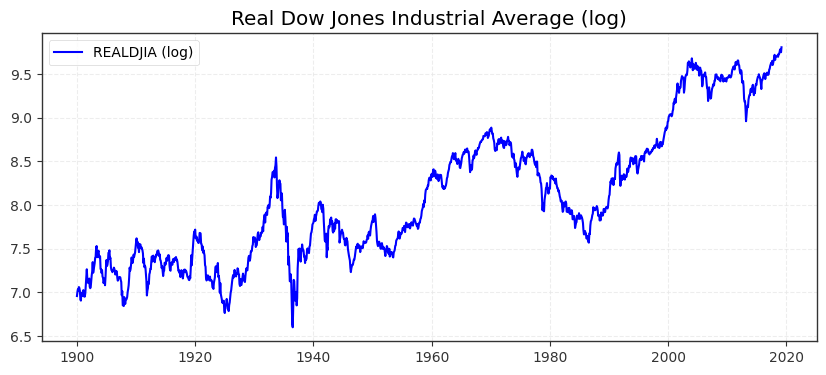

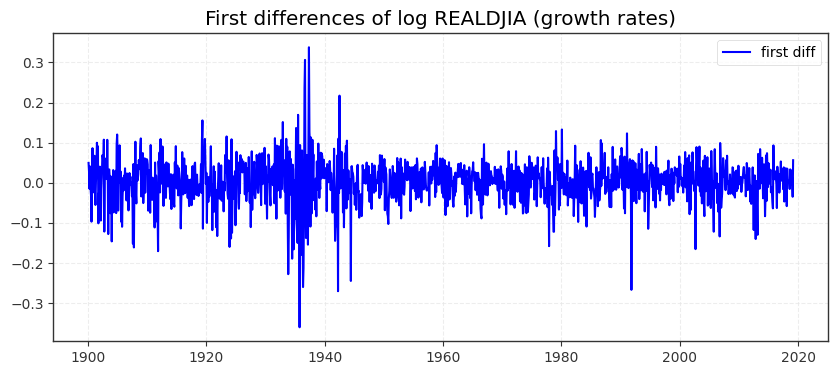


--- Stationarity tests for REALDJIA (log level) ---
ADF: statistic = -0.7057, p-value = 0.8453
KPSS: statistic = 4.4341, p-value = 0.0100

--- Stationarity tests for REALDJIA (first difference) ---
ADF: statistic = -8.9750, p-value = 0.0000
KPSS: statistic = 0.0463, p-value = 0.1000


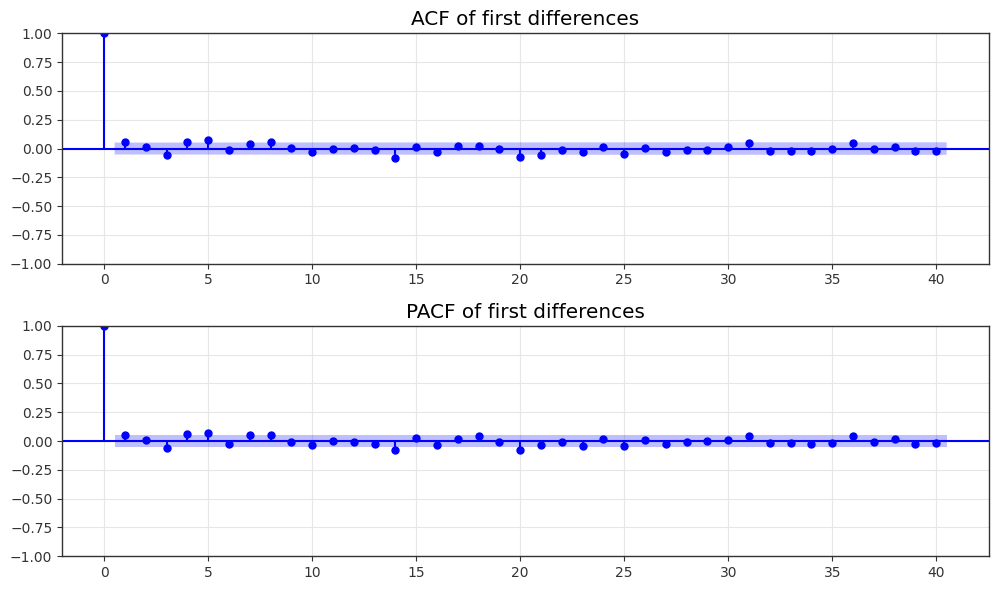


--- AR(5) ---
                               SARIMAX Results                                
Dep. Variable:               REALDJIA   No. Observations:                 1430
Model:                 ARIMA(5, 0, 0)   Log Likelihood                2158.209
Date:                Sun, 15 Feb 2026   AIC                          -4302.419
Time:                        22:39:39   BIC                          -4265.561
Sample:                    02-01-1900   HQIC                         -4288.655
                         - 03-01-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.002      1.137      0.256      -0.001       0.005
ar.L1          0.0561      0.019      2.964      0.003       0.019       0.093
ar.L2          0.0156      0.019     

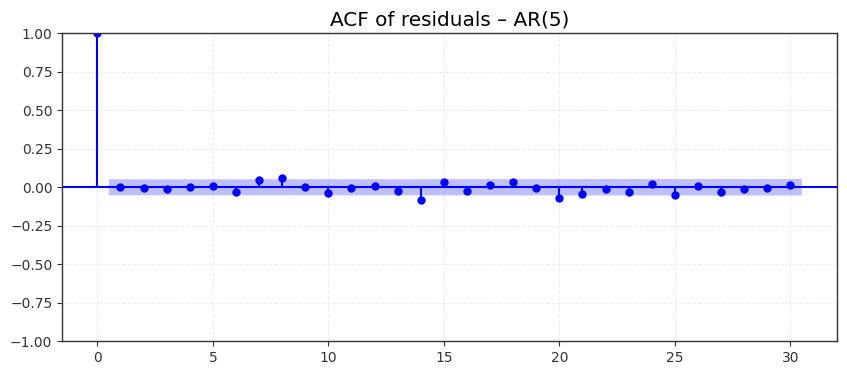

Ljung-Box test (lag=18): p-value = 0.1050

=== Diagnostics for MA(14) ===


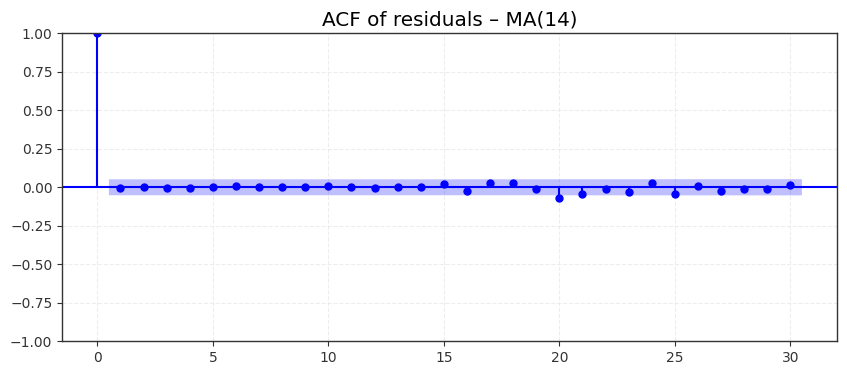

Ljung-Box test (lag=18): p-value = 0.9999

=== Diagnostics for ARMA(1,1) ===


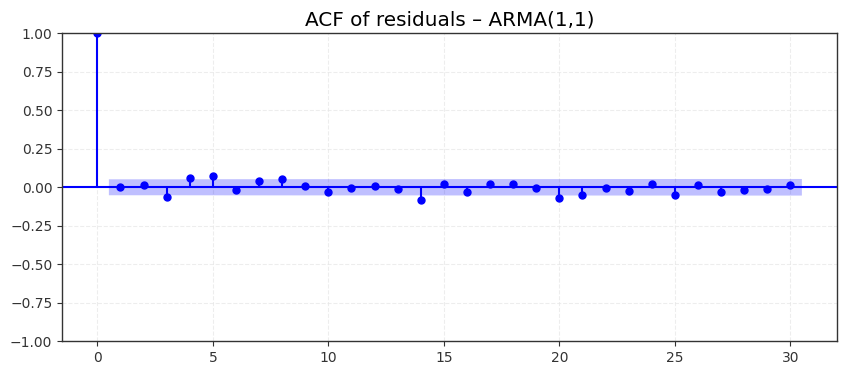

Ljung-Box test (lag=18): p-value = 0.0022


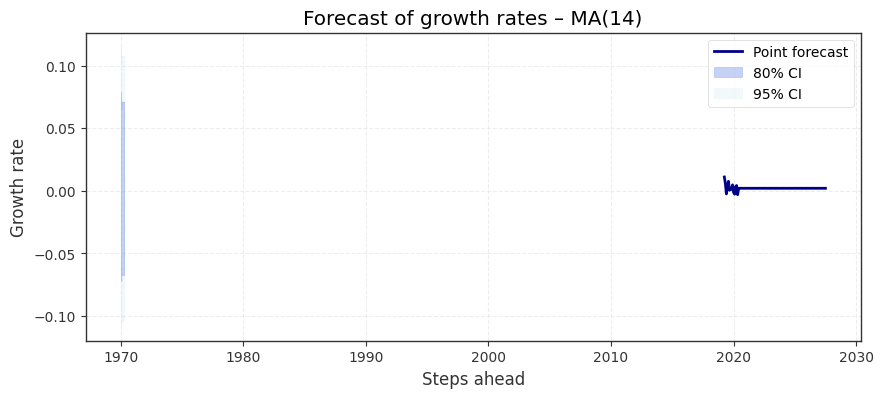


Manual MA forecast (q=14):
1-step: 0.011009
2-step: 0.006075
Library 1-step: 0.011009
Library 2-step: 0.006075
ARIMA(0,1,14) estimation failed: In models with integration (`d > 0`) or seasonal integration (`D > 0`), trend terms of lower order than `d + D` cannot be (as they would be eliminated due to the differencing operation). For example, a constant cannot be included in an ARIMA(1, 1, 1) model, but including a linear trend, which would have the same effect as fitting a constant to the differenced data, is allowed.


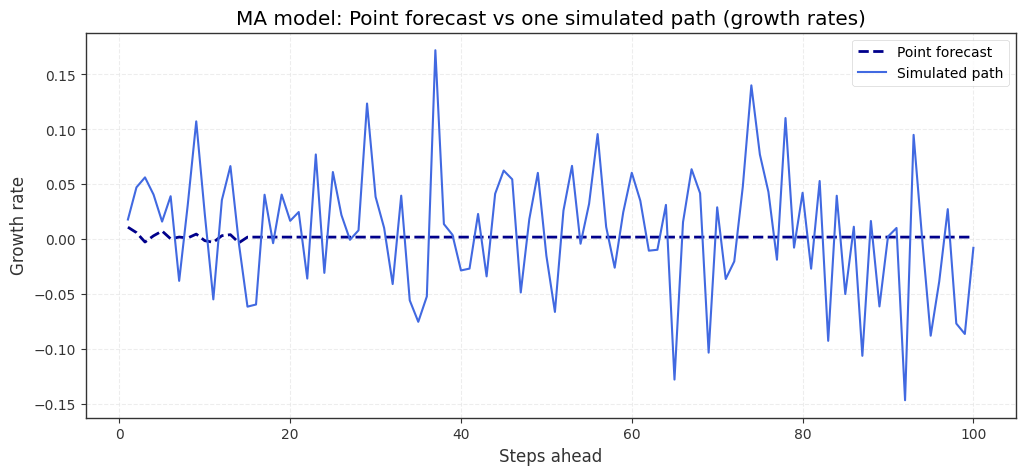


All tasks completed. AR, MA, ARMA models assessed; forecasts only for MA.


In [ ]:
# -*- coding: utf-8 -*-
"""
Time Series Analysis: AR, MA, ARMA models for REALDJIA (log index)
Data: DJA.xls (column REALDJIA, already in logs)
Tasks:
- Visualize first differences
- Build AR(5), MA(14) (or MA(5) fallback), ARMA(1,1) models
- Diagnostics for all three models
- Forecasts (point & interval) for 100 steps – only for MA model
- Compare forecasts for levels and differences – only for MA
- Manual 1- and 2-step ahead forecasts – only for MA
- Imitation forecast – only for MA

Graph design: white background, blue color scheme.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings("ignore")

# ===================== GRAPH STYLE SETTINGS =====================
# Set white background and blue color palette
plt.rcParams['figure.facecolor'] = 'white'          # background of the figure
plt.rcParams['axes.facecolor'] = 'white'            # background of the plot area
plt.rcParams['axes.edgecolor'] = '0.2'              # dark gray axes lines
plt.rcParams['axes.labelcolor'] = '0.2'
plt.rcParams['xtick.color'] = '0.2'
plt.rcParams['ytick.color'] = '0.2'
plt.rcParams['grid.color'] = '0.9'                  # very light gray grid
plt.rcParams['lines.color'] = 'blue'                # default line color
plt.rcParams['patch.facecolor'] = 'blue'            # default fill color
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=['blue', 'royalblue', 'cornflowerblue', 'steelblue'])
# ================================================================

# ------------------------------
# 1. Load and prepare data
# ------------------------------
file_path = "DJA.xls"
df = pd.read_excel(file_path, usecols=["REALDJIA"])
df.dropna(inplace=True)
df.index = pd.date_range(start="1900-01-01", periods=len(df), freq="MS")
series = df["REALDJIA"]
print("Data range:", series.index[0], "to", series.index[-1])
print("Number of observations:", len(series))

# Plot original series
plt.figure(figsize=(10,4))
plt.plot(series, label="REALDJIA (log)", color='blue')
plt.title("Real Dow Jones Industrial Average (log)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# ------------------------------
# 2. First differences: visuals and stationarity tests
# ------------------------------
diff_series = series.diff().dropna()
y = diff_series

# Visuals of first differences
plt.figure(figsize=(10,4))
plt.plot(y, label="first diff", color='blue')
plt.title("First differences of log REALDJIA (growth rates)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Stationarity tests
def stationarity_tests(series, name):
    print(f"\n--- Stationarity tests for {name} ---")
    adf_stat, adf_pval, _, _, _, _ = adfuller(series, autolag="AIC")
    print(f"ADF: statistic = {adf_stat:.4f}, p-value = {adf_pval:.4f}")
    kpss_stat, kpss_pval, _, _ = kpss(series, regression="c", nlags="auto")
    print(f"KPSS: statistic = {kpss_stat:.4f}, p-value = {kpss_pval:.4f}")

stationarity_tests(series, "REALDJIA (log level)")
stationarity_tests(y, "REALDJIA (first difference)")

# ------------------------------
# 3. Model identification: ACF and PACF
# ------------------------------
fig, axes = plt.subplots(2,1, figsize=(10,6))
plot_acf(y, ax=axes[0], lags=40, title="ACF of first differences", color='blue')
plot_pacf(y, ax=axes[1], lags=40, title="PACF of first differences", color='blue')
plt.tight_layout()
plt.show()

# ------------------------------
# 4. Estimate all three candidate models on first differences
# ------------------------------
models = {}        # dictionary for all three models
ma_model = None    # will hold the MA model (MA(14) or fallback) for forecasts

# AR(5)
try:
    model_ar5 = ARIMA(y, order=(5,0,0), trend='c').fit(method_kwargs={'disp':False})
    models['AR(5)'] = model_ar5
    print("\n--- AR(5) ---")
    print(model_ar5.summary())
except:
    print("AR(5) estimation failed.")

# MA(14) – try; if fails, use MA(5) as fallback and store as ma_model
try:
    model_ma14 = ARIMA(y, order=(0,0,14), trend='c').fit(method_kwargs={'disp':False})
    models['MA(14)'] = model_ma14
    ma_model = model_ma14
    print("\n--- MA(14) ---")
    print(model_ma14.summary())
except:
    print("MA(14) estimation failed. Trying MA(5) as fallback.")
    model_ma5 = ARIMA(y, order=(0,0,5), trend='c').fit(method_kwargs={'disp':False})
    models['MA(5)'] = model_ma5
    ma_model = model_ma5
    print("\n--- MA(5) ---")
    print(model_ma5.summary())

# ARMA(1,1)
try:
    model_arma11 = ARIMA(y, order=(1,0,1), trend='c').fit(method_kwargs={'disp':False})
    models['ARMA(1,1)'] = model_arma11
    print("\n--- ARMA(1,1) ---")
    print(model_arma11.summary())
except:
    print("ARMA(1,1) estimation failed.")

# ------------------------------
# 5. Diagnostic checks for all models
# ------------------------------
for name, mod in models.items():
    print(f"\n=== Diagnostics for {name} ===")
    resid = mod.resid
    # Use statsmodels' plot_acf with blue color
    fig, ax = plt.subplots(figsize=(10,4))
    plot_acf(resid, ax=ax, lags=30, title=f"ACF of residuals – {name}", color='blue')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    lb_test = acorr_ljungbox(resid, lags=[18], return_df=True)
    print(f"Ljung-Box test (lag=18): p-value = {lb_test.iloc[0,1]:.4f}")

# ------------------------------
# 6. Forecasts for growth rates (first differences) – 100 steps (only for MA)
# ------------------------------
if ma_model is not None:
    forecast_steps = 100
    fc = ma_model.get_forecast(steps=forecast_steps)
    fc_df_95 = fc.summary_frame(alpha=0.05)
    fc_df_80 = fc.summary_frame(alpha=0.20)  # 80% CI

    forecast_growth = {
        'mean': fc.predicted_mean,
        'ci_95_lower': fc_df_95['mean_ci_lower'],
        'ci_95_upper': fc_df_95['mean_ci_upper'],
        'ci_80_lower': fc_df_80['mean_ci_lower'],
        'ci_80_upper': fc_df_80['mean_ci_upper']
    }

    # Plot forecasts for growth rates with intervals (blue shades)
    plt.figure(figsize=(10,4))
    plt.plot(forecast_growth['mean'], label='Point forecast', color='darkblue', linewidth=2)
    plt.fill_between(range(1, forecast_steps+1),
                     forecast_growth['ci_80_lower'], forecast_growth['ci_80_upper'],
                     alpha=0.3, color='royalblue', label='80% CI')
    plt.fill_between(range(1, forecast_steps+1),
                     forecast_growth['ci_95_lower'], forecast_growth['ci_95_upper'],
                     alpha=0.15, color='lightblue', label='95% CI')
    plt.title(f"Forecast of growth rates – {list(models.keys())[list(models.values()).index(ma_model)]}")
    plt.xlabel("Steps ahead")
    plt.ylabel("Growth rate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # ------------------------------
    # 7. Manual 1- and 2-step ahead forecasts for the MA model
    # ------------------------------
    params = ma_model.params
    const = params['const']
    ma_coeffs = [params[f'ma.L{i+1}'] for i in range(ma_model.model.order[2])]  # order[2] is q
    q = len(ma_coeffs)

    residuals = ma_model.resid.values
    last_residuals = residuals[-q:][::-1]  # most recent first

    # 1-step ahead
    y1_manual = const + sum(ma_coeffs[i] * last_residuals[i] for i in range(q))

    # 2-step ahead (errors beyond t are zero)
    if q >= 2:
        y2_manual = const + sum(ma_coeffs[i] * last_residuals[i-1] for i in range(1, q))
    else:
        y2_manual = const

    print(f"\nManual MA forecast (q={q}):")
    print(f"1-step: {y1_manual:.6f}")
    print(f"2-step: {y2_manual:.6f}")

    # Compare with library forecasts
    fc_lib = ma_model.forecast(steps=2)
    print(f"Library 1-step: {fc_lib[0]:.6f}")
    print(f"Library 2-step: {fc_lib[1]:.6f}")

    # ------------------------------
    # 8. Forecasts for the level (original series) using ARIMA(0,1,q)
    # ------------------------------
    q_order = ma_model.model.order[2]
    level_order = (0, 1, q_order)
    level_model_name = f"ARIMA(0,1,{q_order})"

    try:
        level_model = ARIMA(series, order=level_order, trend='c').fit(method_kwargs={'disp':False})
        print(f"\n--- {level_model_name} ---")
        print(level_model.summary())

        # Forecast for level (100 steps)
        level_forecast = level_model.get_forecast(steps=forecast_steps).predicted_mean

        # Plot level forecast
        plt.figure(figsize=(12,6))
        plt.plot(level_forecast, label=level_model_name, color='blue')
        plt.plot(series, label='Historical level', color='darkblue', linestyle='--')
        plt.title("Point forecast of log REALDJIA (level) – MA-based")
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()
    except Exception as e:
        print(f"{level_model_name} estimation failed: {e}")

    # ------------------------------
    # 9. Imitation (simulated) forecast for the MA model
    # ------------------------------
    sigma = np.sqrt(ma_model.params['sigma2'])
    h = 100
    y_sim = np.zeros(h)
    e_sim = np.zeros(h)

    past_errors = list(last_residuals)  # e_t, e_{t-1}, ...

    for t in range(h):
        e_sim[t] = np.random.normal(0, sigma)
        ma_terms = 0
        for i in range(q):
            if t - i >= 0:
                ma_terms += ma_coeffs[i] * e_sim[t - i]
            else:
                ma_terms += ma_coeffs[i] * past_errors[-(t - i)]
        y_sim[t] = const + ma_terms + e_sim[t]

    plt.figure(figsize=(12,5))
    plt.plot(range(1, h+1), forecast_growth['mean'], label='Point forecast',
             linestyle='--', color='darkblue', linewidth=2)
    plt.plot(range(1, h+1), y_sim, label='Simulated path', color='royalblue', linewidth=1.5)
    plt.title(f"MA model: Point forecast vs one simulated path (growth rates)")
    plt.xlabel("Steps ahead")
    plt.ylabel("Growth rate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # ------------------------------
    # 10. Export forecasts to Excel (optional) – only MA
    # ------------------------------
    # Uncomment to save:
    # with pd.ExcelWriter('forecasts_REALDJIA_MA.xlsx') as writer:
    #     df_fc = pd.DataFrame({
    #         'mean': forecast_growth['mean'],
    #         'lower_80': forecast_growth['ci_80_lower'],
    #         'upper_80': forecast_growth['ci_80_upper'],
    #         'lower_95': forecast_growth['ci_95_lower'],
    #         'upper_95': forecast_growth['ci_95_upper']
    #     })
    #     df_fc.to_excel(writer, sheet_name='MA_forecast')
    #     if level_model is not None:
    #         df_level = pd.DataFrame({'mean': level_forecast})
    #         df_level.to_excel(writer, sheet_name='MA_level_forecast')

else:
    print("No MA model was successfully estimated – cannot produce forecasts.")

print("\nAll tasks completed. AR, MA, ARMA models assessed; forecasts only for MA.")

In [ ]:
print(last_residuals)

[ 0.05955442 -0.03597968  0.00425953  0.03030392  0.01226334 -0.00233579
  0.03636211 -0.02596343  0.00265467  0.01064203 -0.00389009  0.00093444
  0.03851327 -0.05531734]
